# Lab 05 – Image Segmentation

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

IMG_TASK1 = "images/sudoku.png"

def show(imgs, titles, cols, save, size=(4, 4)):
    rows = int(np.ceil(len(imgs) / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(size[0] * cols, size[1] * rows))
    for ax in np.array(axs).ravel():
        ax.axis("off")
    for ax, im, t in zip(np.array(axs).ravel(), imgs, titles):
        ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        ax.set_title(t, fontsize=10)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, save), dpi=150, bbox_inches="tight", pad_inches=0.2)
    plt.show()

def region_ink(mask, n=3):
    h, w = mask.shape
    return np.array([[(mask[i*h//n:(i+1)*h//n, j*w//n:(j+1)*w//n] > 0).mean()
                      for j in range(n)] for i in range(n)]).round(2)

## Task 1

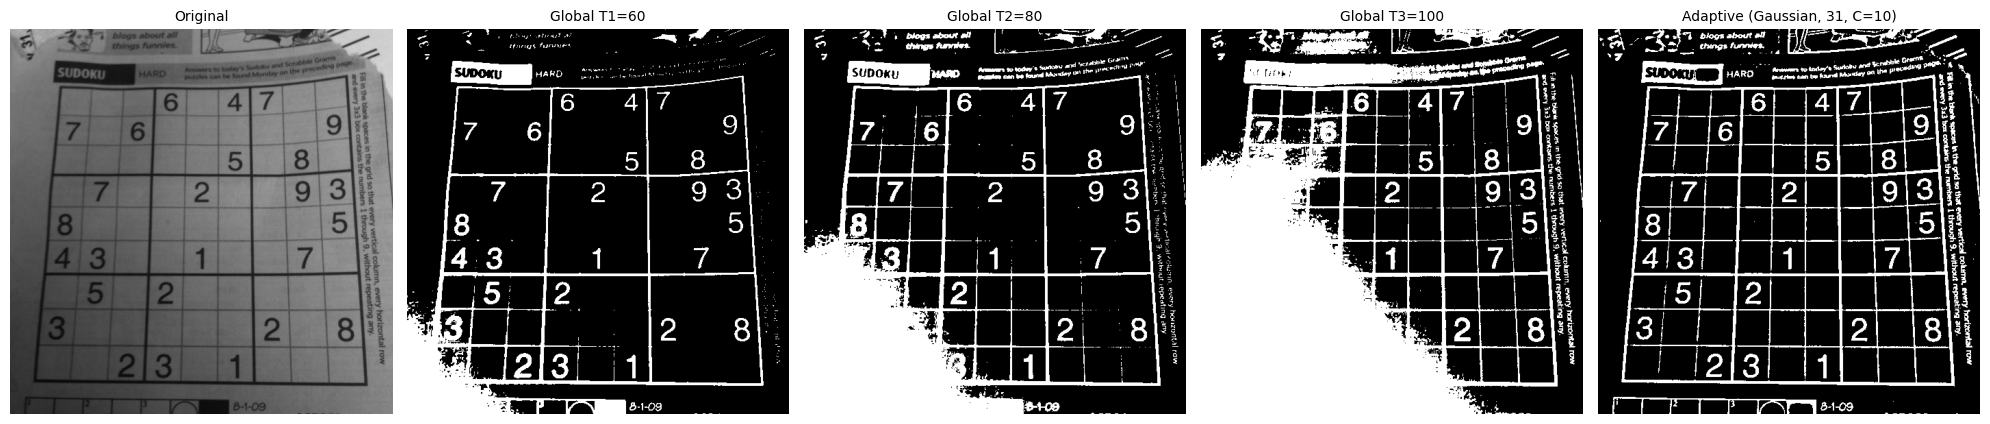

T1=60     ink pixels:  12.9%
[[0.12 0.06 0.05]
 [0.1  0.09 0.07]
 [0.47 0.15 0.05]]
T2=80     ink pixels:  25.8%
[[0.17 0.13 0.09]
 [0.33 0.12 0.1 ]
 [0.96 0.34 0.08]]
T3=100    ink pixels:  45.3%
[[0.33 0.31 0.17]
 [0.93 0.23 0.16]
 [1.   0.79 0.16]]
Adaptive  ink pixels:  15.3%
[[0.16 0.17 0.19]
 [0.12 0.15 0.19]
 [0.11 0.16 0.13]]
Mean brightness, left / middle / right third: [80.8, 99.5, 125.1]


True

In [2]:
gray = cv2.imread(IMG_TASK1, cv2.IMREAD_GRAYSCALE)

THRESHOLDS = [60, 80, 100]
global_masks = [cv2.threshold(gray, t, 255, cv2.THRESH_BINARY_INV)[1] for t in THRESHOLDS]

BLOCK, C_CONST = 31, 10
adaptive_mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY_INV, BLOCK, C_CONST)

show([gray] + global_masks + [adaptive_mask],
     ["Original", "Global T1=60", "Global T2=80", "Global T3=100", f"Adaptive (Gaussian, {BLOCK}, C={C_CONST})"],
     cols=5, save="task1_comparison.png", size=(4, 4.2))

for name, m in zip(["T1=60", "T2=80", "T3=100", "Adaptive"], global_masks + [adaptive_mask]):
    print(f"{name:9s} ink pixels: {(m > 0).mean()*100:5.1f}%")
    print(region_ink(m))

print("Mean brightness, left / middle / right third:",
      [round(float(gray[:, i*gray.shape[1]//3:(i+1)*gray.shape[1]//3].mean()), 1) for i in range(3)])

BEST_GLOBAL = 0
cv2.imwrite(os.path.join(OUT_DIR, "task1_best_global.png"), global_masks[BEST_GLOBAL])
cv2.imwrite(os.path.join(OUT_DIR, "task1_adaptive_final.png"), adaptive_mask)

In [3]:
print("PARAMETERS")
print("Global thresholds: 60, 80, 100 -> spread across the dark-to-bright range of the page (Otsu would pick ~96).")
print(f"Adaptive: Gaussian, blockSize={BLOCK}, C={C_CONST} -> neighbourhood spans a digit and its local paper; C=10 suppresses paper texture.")
print()
print("ANALYSIS")
print("1. Best global result: T1=60 (least flooding), yet it still marks 47% of the bottom-left third as ink and gives weaker strokes on the bright right side.")
print("2. Failing regions: the dark bottom-left (mean brightness ~81 vs ~125 on the right). At T2=80 and T3=100 that region becomes 96% and 100% ink, i.e. background is read as text.")
print("3. Selected combination: adaptive Gaussian, blockSize=31, C=10 -> ink share stays between 11% and 19% in all nine regions, with digits and grid lines intact.")
print("4. Why does a single threshold struggle when illumination changes?")
print("   One cutoff assumes the paper has the same brightness everywhere. Here the paper is ~80 on the left and ~125 on the right, so any value that separates")
print("   text from paper on one side lies above the paper (or below the text) on the other side. Adaptive thresholding compares each pixel to its own neighbourhood.")

PARAMETERS
Global thresholds: 60, 80, 100 -> spread across the dark-to-bright range of the page (Otsu would pick ~96).
Adaptive: Gaussian, blockSize=31, C=10 -> neighbourhood spans a digit and its local paper; C=10 suppresses paper texture.

ANALYSIS
1. Best global result: T1=60 (least flooding), yet it still marks 47% of the bottom-left third as ink and gives weaker strokes on the bright right side.
2. Failing regions: the dark bottom-left (mean brightness ~81 vs ~125 on the right). At T2=80 and T3=100 that region becomes 96% and 100% ink, i.e. background is read as text.
3. Selected combination: adaptive Gaussian, blockSize=31, C=10 -> ink share stays between 11% and 19% in all nine regions, with digits and grid lines intact.
4. Why does a single threshold struggle when illumination changes?
   One cutoff assumes the paper has the same brightness everywhere. Here the paper is ~80 on the left and ~125 on the right, so any value that separates
   text from paper on one side lies above 

## Task 2

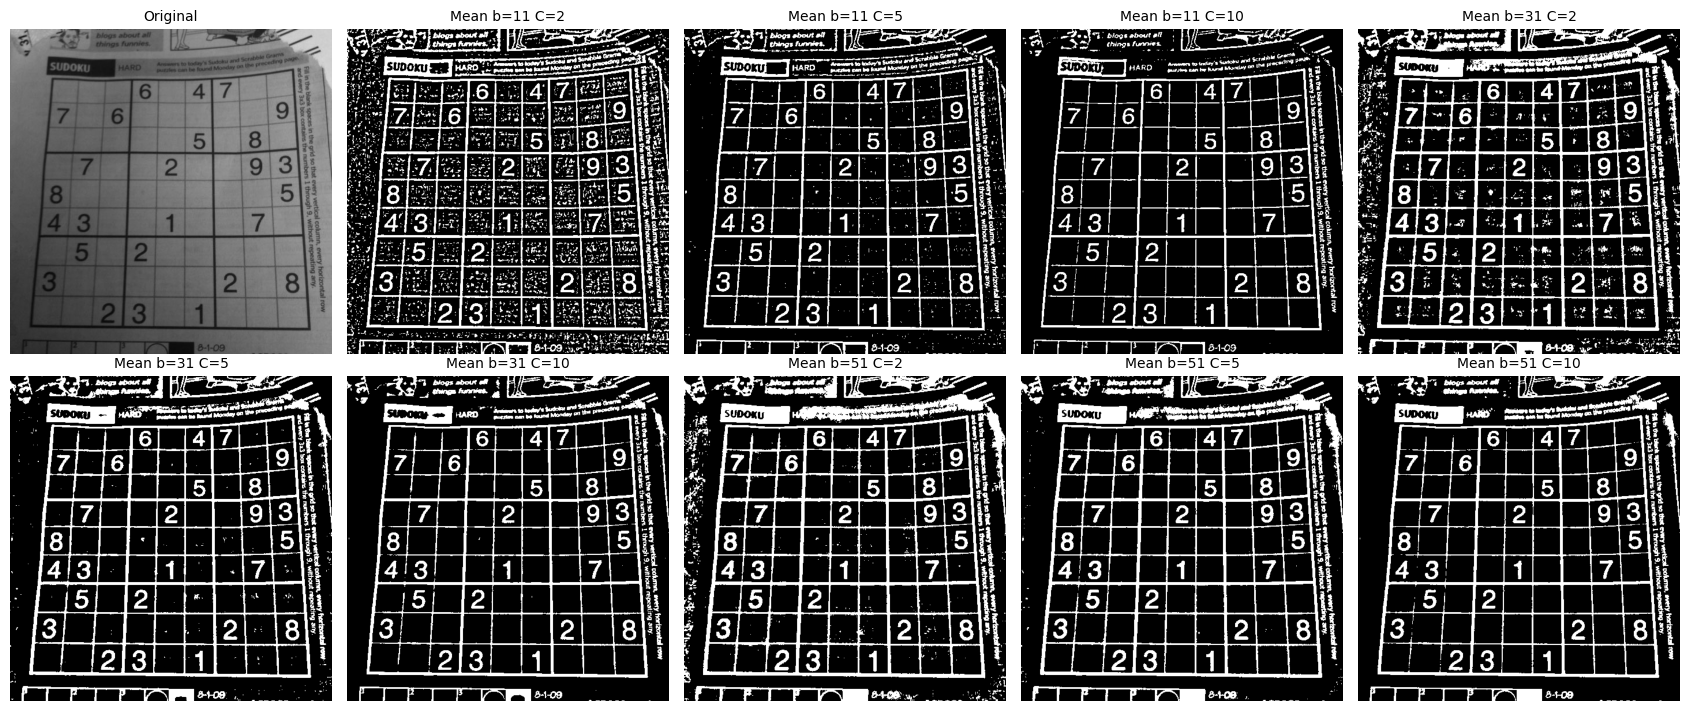

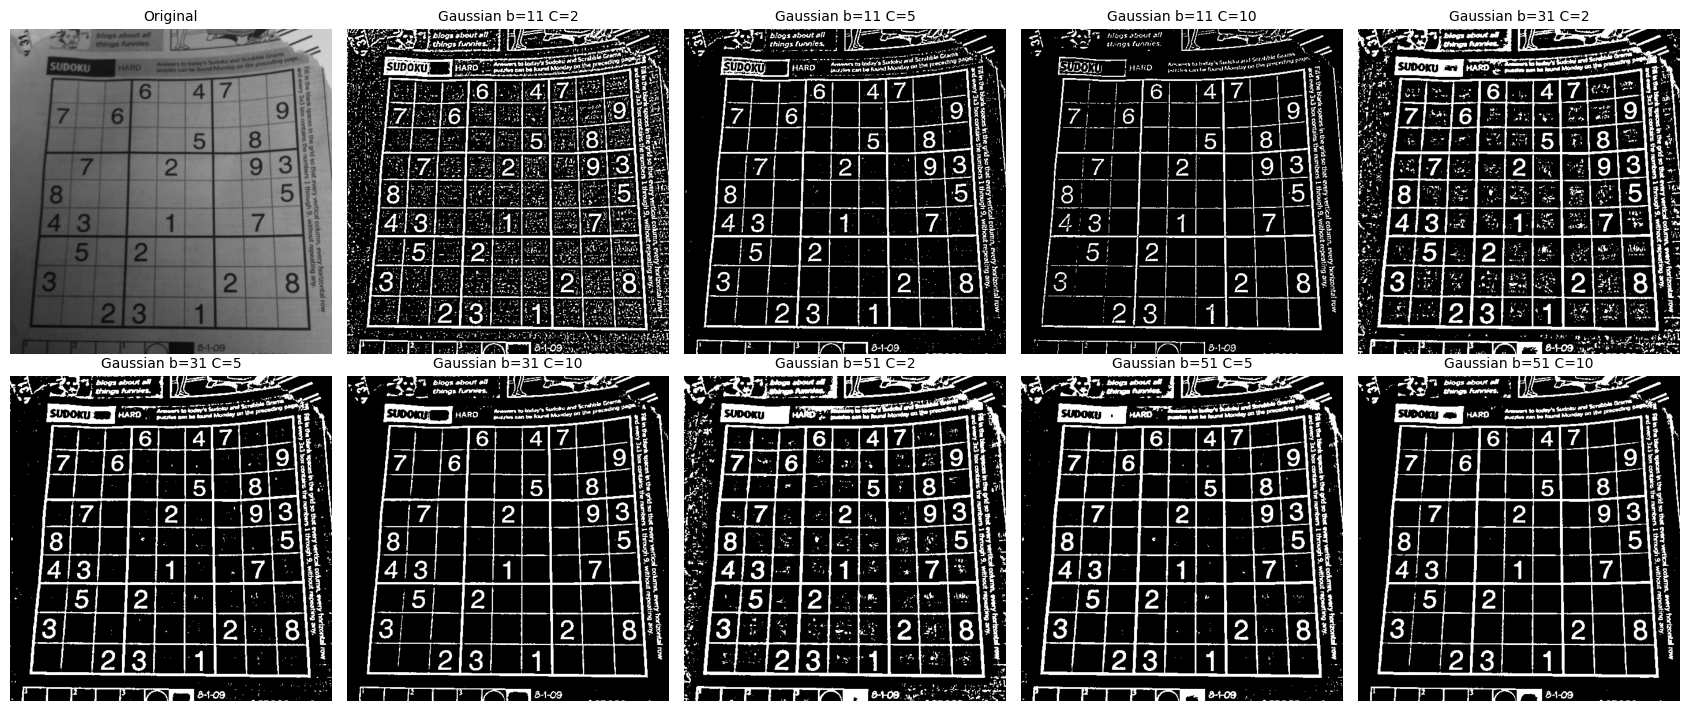

method    block   C   ink %  speckles
Mean         11   2    25.6      1510
Mean         11   5    17.4       513
Mean         11  10    14.3       106
Mean         31   2    24.9       512
Mean         31   5    20.3       202
Mean         31  10    17.4        66
Mean         51   2    24.1       308
Mean         51   5    20.9       113
Mean         51  10    18.1        59
Gaussian     11   2    22.4      3153
Gaussian     11   5    14.4       522
Gaussian     11  10    11.0       145
Gaussian     31   2    23.9       950
Gaussian     31   5    18.2       299
Gaussian     31  10    15.3        64
Gaussian     51   2    23.6       638
Gaussian     51   5    19.4       190
Gaussian     51  10    16.6        51


In [4]:
gray2 = cv2.imread(IMG_TASK1, cv2.IMREAD_GRAYSCALE)

BLOCKS = [11, 31, 51]
CS = [2, 5, 10]
METHODS = {"Mean": cv2.ADAPTIVE_THRESH_MEAN_C, "Gaussian": cv2.ADAPTIVE_THRESH_GAUSSIAN_C}

results = {}
for mname, meth in METHODS.items():
    for b in BLOCKS:
        for c in CS:
            results[(mname, b, c)] = cv2.adaptiveThreshold(gray2, 255, meth, cv2.THRESH_BINARY_INV, b, c)

def speckle_count(mask, max_area=4):
    n, _, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    return int((stats[1:, cv2.CC_STAT_AREA] <= max_area).sum())

for mname in METHODS:
    keys = [k for k in results if k[0] == mname]
    show([gray2] + [results[k] for k in keys],
         ["Original"] + [f"{k[0]} b={k[1]} C={k[2]}" for k in keys],
         cols=5, save=f"task2_{mname.lower()}_grid.png", size=(3.4, 3.6))

print(f"{'method':9s}{'block':>6s}{'C':>4s}{'ink %':>8s}{'speckles':>10s}")
for k, m in results.items():
    print(f"{k[0]:9s}{k[1]:6d}{k[2]:4d}{(m > 0).mean()*100:8.1f}{speckle_count(m):10d}")

for k, m in results.items():
    cv2.imwrite(os.path.join(OUT_DIR, f"task2_{k[0].lower()}_b{k[1]}_c{k[2]}.png"), m)

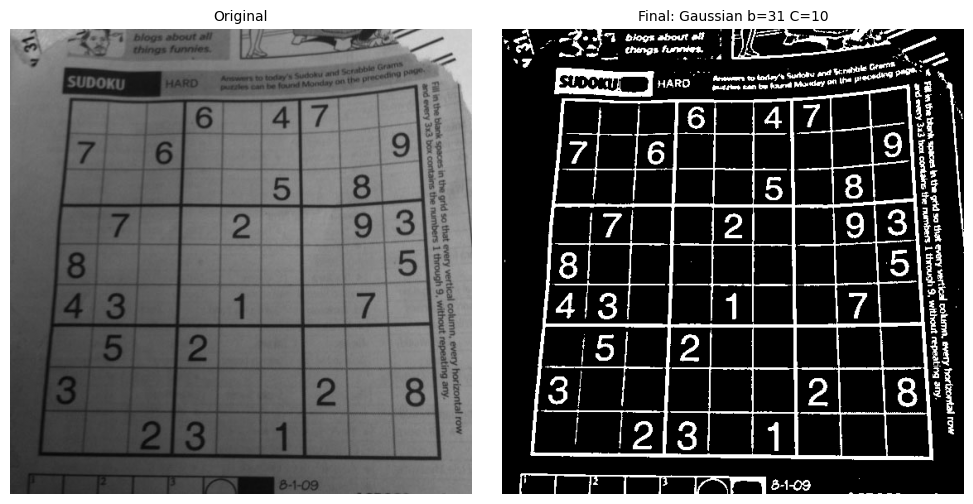

PARAMETERS
blockSize: 11, 31, 51 | C: 2, 5, 10 | methods: Mean, Gaussian (18 results, saved to outputs/)

ANALYSIS
1. Neighbourhood too small (b=11): window is about the size of a stroke, so paper texture is read as ink (Gaussian b=11 C=2: 3153 speckles) and large dark areas such as the SUDOKU box turn hollow.
2. Neighbourhood too large (b=51): the window averages across the lighting gradient and behaves more like a global threshold; blotches appear near the page edges and shadow (Mean b=51 C=2).
3. Increasing C: threshold moves further below the local mean, so ink share and noise fall (Gaussian b=31: 23.9% -> 18.2% -> 15.3%; speckles 950 -> 299 -> 64). Too high a C thins faint strokes (b=11 C=10 digit 4).
4. Cleanest combination: Gaussian, b=31, C=10 (64 speckles, strokes and grid intact). Gaussian b=51 C=10 is similar (51 speckles) but adapts less to local lighting.
5. Adaptive method: Mean gives fewer speckles at low C (b=31 C=2: 512 vs 950), but at C=10 the two are close (66 vs 64)

In [5]:
FINAL = ("Gaussian", 31, 10)
show([gray2, results[FINAL]], ["Original", "Final: Gaussian b=31 C=10"], cols=2, save="task2_final.png", size=(5, 5))
cv2.imwrite(os.path.join(OUT_DIR, "task2_final.png"), results[FINAL])

print("PARAMETERS")
print("blockSize: 11, 31, 51 | C: 2, 5, 10 | methods: Mean, Gaussian (18 results, saved to outputs/)")
print()
print("ANALYSIS")
print("1. Neighbourhood too small (b=11): window is about the size of a stroke, so paper texture is read as ink (Gaussian b=11 C=2: 3153 speckles) and large dark areas such as the SUDOKU box turn hollow.")
print("2. Neighbourhood too large (b=51): the window averages across the lighting gradient and behaves more like a global threshold; blotches appear near the page edges and shadow (Mean b=51 C=2).")
print("3. Increasing C: threshold moves further below the local mean, so ink share and noise fall (Gaussian b=31: 23.9% -> 18.2% -> 15.3%; speckles 950 -> 299 -> 64). Too high a C thins faint strokes (b=11 C=10 digit 4).")
print("4. Cleanest combination: Gaussian, b=31, C=10 (64 speckles, strokes and grid intact). Gaussian b=51 C=10 is similar (51 speckles) but adapts less to local lighting.")
print("5. Adaptive method: Mean gives fewer speckles at low C (b=31 C=2: 512 vs 950), but at C=10 the two are close (66 vs 64) and Gaussian is cleaner along the page edges, so Gaussian is used.")